# PCA, t-SNE y Autoencoder en acción (digits)


Proyecto: PCA y t-SNE en acción con autoencoder
Dataset: digits (sklearn)
Descripción:
 - Aplica PCA (2D) y genera scatter plot.
 - Aplica t-SNE con dos valores de perplejidad.
 - Aplica un autoencoder para reducción a 2D.
 - Compara visualmente las técnicas.

Instrucciones del autor (Yuri):
 - Explicar los ejercicios paso a paso, numerando los pasos.
 - Usar lenguaje claro y pedagógico

In [6]:

# ==========================
# 1. Importar librerías
# ==========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras import layers, Model



In [7]:

# ==========================
# 2. Fijar semillas aleatorias
# ==========================

# Paso 1: fijar semilla para reproducibilidad básica
np.random.seed(42)
tf.random.set_seed(42)



In [8]:

# ==========================
# 3. Cargar y preprocesar el dataset
# ==========================

# Paso 2: cargar el dataset digits
# X: matriz de características (n_muestras x 64)
# y: etiquetas (dígitos 0-9)

digits = load_digits()
X = digits.data
y = digits.target

# Paso 3: escalar los datos con StandardScaler
# Interpretación: cada columna tendrá media 0 y varianza 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



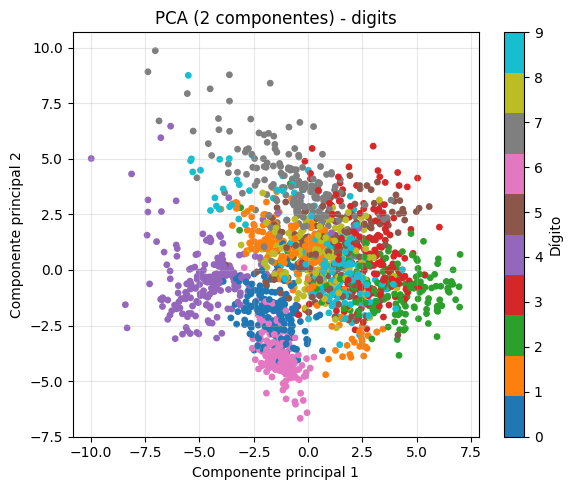

In [9]:

# ==========================
# 4. PCA a 2 componentes
# ==========================

# Paso 4: crear el modelo PCA para 2 componentes principales
pca = PCA(n_components=2, random_state=42)

# Paso 5: ajustar PCA y transformar los datos
X_pca = pca.fit_transform(X_scaled)

# Paso 6: graficar el resultado de PCA
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=15)
plt.colorbar(scatter, label='Dígito')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('PCA (2 componentes) - digits')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



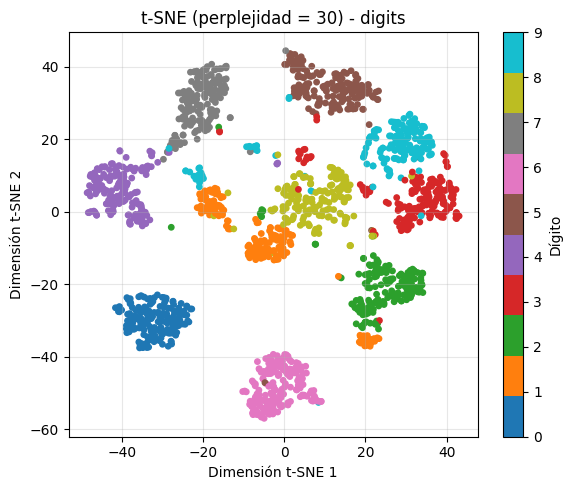

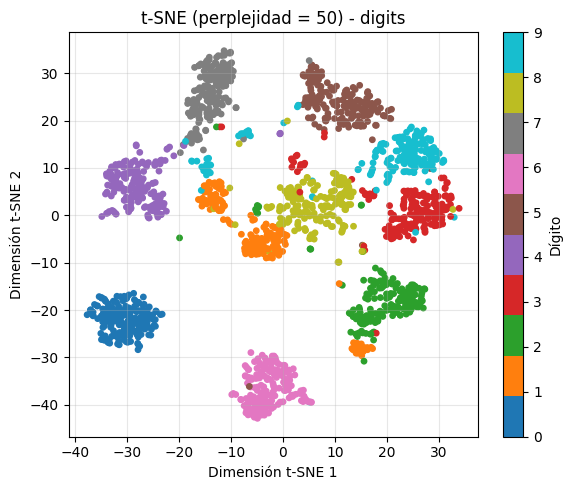

In [10]:

# ==========================
# 5. t-SNE con dos perplejidades
# ==========================

# Paso 7: aplicar t-SNE con perplejidad 30
# Nota: t-SNE es más costoso; reducimos primero con PCA a 30 dims para velocidad.
pca_30 = PCA(n_components=30, random_state=42)
X_pca_30 = pca_30.fit_transform(X_scaled)

perplexities = [30, 50]
X_tsne_results = {}

for perp in perplexities:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X_pca_30)
    X_tsne_results[perp] = X_tsne

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15)
    plt.colorbar(scatter, label='Dígito')
    plt.xlabel('Dimensión t-SNE 1')
    plt.ylabel('Dimensión t-SNE 2')
    plt.title(f't-SNE (perplejidad = {perp}) - digits')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2036 - val_loss: 0.9549
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0390 - val_loss: 0.8070
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9788 - val_loss: 0.7930
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9550 - val_loss: 0.7759
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9385 - val_loss: 0.7671
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9284 - val_loss: 0.7606
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9179 - val_loss: 0.7559
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9092 - val_loss: 0.7508
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9039 - val_loss: 0.7477
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9003 - val_loss: 0.7451
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8967 - val_loss: 0.7426
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8940 - val_lo

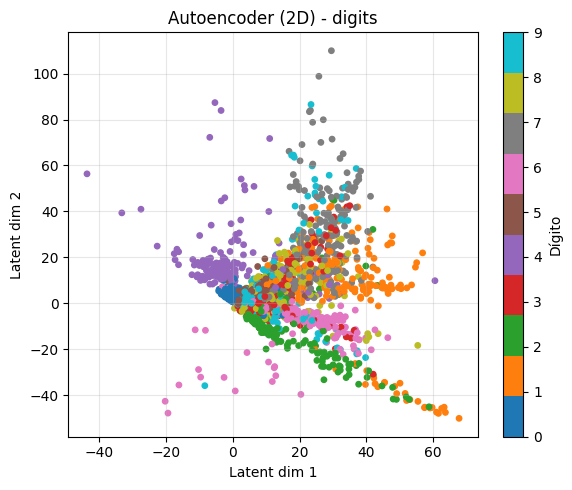

In [11]:

# ==========================
# 6. Autoencoder para reducción a 2D
# ==========================

# Paso 8: definir dimensiones del autoencoder
input_dim = X_scaled.shape[1]  # 64 features
encoding_dim = 2               # espacio latente 2D

# Paso 9: construir el modelo autoencoder
input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(32, activation='relu')(input_layer)
encoded = layers.Dense(16, activation='relu')(encoded)
latent = layers.Dense(encoding_dim, activation='linear', name='latent_space')(encoded)

# Decoder
decoded = layers.Dense(16, activation='relu')(latent)
decoded = layers.Dense(32, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Modelo completo
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Modelo encoder separado
encoder = Model(inputs=input_layer, outputs=latent)

# Paso 10: compilar el autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Paso 11: entrenar el autoencoder
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Paso 12: obtener la representación 2D desde el encoder
X_auto_2d = encoder.predict(X_scaled)

# Paso 13: graficar el espacio latente del autoencoder
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_auto_2d[:, 0], X_auto_2d[:, 1], c=y, cmap='tab10', s=15)
plt.colorbar(scatter, label='Dígito')
plt.xlabel('Latent dim 1')
plt.ylabel('Latent dim 2')
plt.title('Autoencoder (2D) - digits')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

